# AI Job Market Salary Prediction - Machine Learning Capstone
## Jerel Velarde | Pillar 5 Capstone

---

In [1]:
# Setup and imports
%matplotlib inline
import sys
import os
sys.path.insert(0, '../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
import umap
import shap
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Imports completed successfully!")

Imports completed successfully!


# Step 1: Problem Understanding & Framing

## Business Problem
The global AI and data science job market is rapidly evolving with significant salary variations based on experience, location, role, and company characteristics. Data professionals need insights into salary expectations, and organizations need benchmarks for compensation planning.

## Data Science Problem
**Objective**: Build a predictive model to estimate salary in USD for AI/ML professionals based on available features (experience level, job title, location, employment type, company size, etc.)

## Task Type
**Supervised Regression**: Predicting continuous salary values (salary_in_usd)

## Target Variable
- **salary_in_usd**: Annual salary in US dollars
- **Type**: Continuous numerical variable
- **Range**: Expected $20,000 - $600,000+

## Evaluation Metrics
1. **RMSE (Root Mean Squared Error)**: Penalizes large errors more heavily - important for catching outlier mispredictions
2. **MAE (Mean Absolute Error)**: Average magnitude of prediction errors in dollar amounts
3. **R² Score**: Proportion of variance explained by the model (0-1 scale)

## Key Features
- **experience_level**: Career stage (Entry, Mid, Senior, Executive)
- **job_title**: Position type (grouped rare titles as 'Other')
- **employment_type**: Full-time, Part-time, Contractor, Freelancer
- **company_location**: Country code of company headquarters
- **company_size**: Small, Medium, Large
- **remote_ratio**: Percentage of remote work (0, 50, 100)
- **work_year**: Year of employment

## Success Criteria
- Model explains >80% of salary variance (R² > 0.80)
- RMSE < $50,000
- Interpretable feature importance for business insights


# Step 2: Dataset Overview

Loading and exploring the AI Job Market salary dataset from Kaggle.

In [2]:
# Load the dataset
df = pd.read_csv('../data/raw/ds_salaries.csv')

# Drop the unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

print("Dataset Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

Dataset Shape:
Rows: 607, Columns: 11

Memory usage: 272.36 KB


In [3]:
# Display first few rows
print("First 5 rows:")
print(df.head())

First 5 rows:
   work_year experience_level employment_type                   job_title  \
0       2020               MI              FT              Data Scientist   
1       2020               SE              FT  Machine Learning Scientist   
2       2020               SE              FT           Big Data Engineer   
3       2020               MI              FT        Product Data Analyst   
4       2020               SE              FT   Machine Learning Engineer   

   salary salary_currency  salary_in_usd employee_residence  remote_ratio  \
0   70000             EUR          79833                 DE             0   
1  260000             USD         260000                 JP             0   
2   85000             GBP         109024                 GB            50   
3   20000             USD          20000                 HN             0   
4  150000             USD         150000                 US            50   

  company_location company_size  
0               DE        

In [4]:
# Dataset info
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_in_usd       607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   remote_ratio        607 non-null    int64 
 9   company_location    607 non-null    object
 10  company_size        607 non-null    object
dtypes: int64(4), object(7)
memory usage: 52.3+ KB


In [5]:
# Data Dictionary
data_dict = {
    'Column': df.columns,
    'Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Unique Values': [df[col].nunique() for col in df.columns],
    'Description': [
        'Year of work',
        'Experience level (EN=Entry, MI=Mid, SE=Senior, EX=Executive)',
        'Employment type (FT, PT, CT, FL)',
        'Job title/position',
        'Salary in original currency',
        'Currency code of salary',
        'Salary converted to USD',
        'Country code of employee residence',
        'Remote work ratio (0, 50, 100)',
        'Country code of company location',
        'Company size (S=Small, M=Medium, L=Large)'
    ]
}

data_dict_df = pd.DataFrame(data_dict)
print("\nData Dictionary:")
print(data_dict_df.to_string(index=False))


Data Dictionary:
            Column   Type  Non-Null Count  Unique Values                                                  Description
         work_year  int64             607              3                                                 Year of work
  experience_level object             607              4 Experience level (EN=Entry, MI=Mid, SE=Senior, EX=Executive)
   employment_type object             607              4                             Employment type (FT, PT, CT, FL)
         job_title object             607             50                                           Job title/position
            salary  int64             607            272                                  Salary in original currency
   salary_currency object             607             17                                      Currency code of salary
     salary_in_usd  int64             607            369                                      Salary converted to USD
employee_residence object             

In [6]:
# Statistical summary
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
         work_year        salary  salary_in_usd  remote_ratio
count   607.000000  6.070000e+02     607.000000     607.00000
mean   2021.405272  3.240001e+05  112297.869852      70.92257
std       0.692133  1.544357e+06   70957.259411      40.70913
min    2020.000000  4.000000e+03    2859.000000       0.00000
25%    2021.000000  7.000000e+04   62726.000000      50.00000
50%    2022.000000  1.150000e+05  101570.000000     100.00000
75%    2022.000000  1.650000e+05  150000.000000     100.00000
max    2022.000000  3.040000e+07  600000.000000     100.00000


In [7]:
# Check for missing values and duplicates
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Salary range: ${df['salary_in_usd'].min():,} - ${df['salary_in_usd'].max():,}")


Missing Values:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Duplicate rows: 42
Salary range: $2,859 - $600,000


# Step 3: Data Preprocessing & Exploratory Data Analysis

## Data Cleaning

In [8]:
# Create a copy for processing
df_processed = df.copy()

# Remove duplicates
initial_count = len(df_processed)
df_processed = df_processed.drop_duplicates()
print(f"Removed {initial_count - len(df_processed)} duplicates")

# Check for missing values
print(f"\nMissing values after duplicate removal:")
print(df_processed.isnull().sum().sum())

print(f"\nCleaned dataset shape: {df_processed.shape}")

Removed 42 duplicates

Missing values after duplicate removal:
0

Cleaned dataset shape: (565, 11)


## Feature Engineering

In [9]:
# 1. Ordinal encode experience level
experience_mapping = {
    'EN': 1,  # Entry
    'MI': 2,  # Mid-level
    'SE': 3,  # Senior
    'EX': 4   # Executive
}
df_processed['experience_level_encoded'] = df_processed['experience_level'].map(experience_mapping)

print("Experience level encoding:")
print(f"EN (Entry) = 1")
print(f"MI (Mid) = 2")
print(f"SE (Senior) = 3")
print(f"EX (Executive) = 4")
print(f"\nEncoded values distribution:")
print(df_processed['experience_level_encoded'].value_counts().sort_index())

Experience level encoding:
EN (Entry) = 1
MI (Mid) = 2
SE (Senior) = 3
EX (Executive) = 4

Encoded values distribution:
experience_level_encoded
1     88
2    208
3    243
4     26
Name: count, dtype: int64


In [10]:
# 2. Group rare job titles (< 5 occurrences)
title_counts = df_processed['job_title'].value_counts()
print(f"Job titles before grouping rare: {df_processed['job_title'].nunique()} unique")
print(f"\nTop 10 job titles:")
print(title_counts.head(10))

rare_titles = title_counts[title_counts < 5].index
df_processed['job_title'] = df_processed['job_title'].apply(
    lambda x: 'Other' if x in rare_titles else x
)

print(f"\nJob titles after grouping rare (< 5): {df_processed['job_title'].nunique()} unique")
print(f"\nJob title distribution:")
print(df_processed['job_title'].value_counts())

Job titles before grouping rare: 50 unique

Top 10 job titles:
job_title
Data Scientist                130
Data Engineer                 121
Data Analyst                   82
Machine Learning Engineer      39
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Big Data Engineer               8
Machine Learning Scientist      8
Principal Data Scientist        7
Name: count, dtype: int64

Job titles after grouping rare (< 5): 23 unique

Job title distribution:
job_title
Data Scientist                130
Data Engineer                 121
Data Analyst                   82
Other                          59
Machine Learning Engineer      39
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Machine Learning Scientist      8
Big Data Engineer               8
Data Science Consultant         7
AI Scientist                    7
Principal Data Scientist        7
Data Analytics Manager          7
D

In [11]:
# 3. Create continent feature
country_to_continent = {
    'US': 'North America', 'CA': 'North America', 'MX': 'North America',
    'GB': 'Europe', 'DE': 'Europe', 'FR': 'Europe', 'ES': 'Europe', 'IT': 'Europe',
    'NL': 'Europe', 'SE': 'Europe', 'CH': 'Europe', 'AT': 'Europe', 'BE': 'Europe',
    'DK': 'Europe', 'PL': 'Europe', 'RO': 'Europe', 'CZ': 'Europe', 'GR': 'Europe',
    'PT': 'Europe', 'IE': 'Europe', 'UA': 'Europe', 'HR': 'Europe', 'LV': 'Europe',
    'JP': 'Asia', 'IN': 'Asia', 'CN': 'Asia', 'SG': 'Asia', 'AU': 'Oceania',
    'NZ': 'Oceania', 'BR': 'South America', 'AR': 'South America', 'CL': 'South America',
    'ZA': 'Africa', 'NG': 'Africa', 'EG': 'Africa', 'KE': 'Africa',
    'HN': 'Central America', 'KR': 'Asia', 'RU': 'Europe',
    'TH': 'Asia', 'ID': 'Asia', 'VN': 'Asia', 'MY': 'Asia', 'PH': 'Asia',
    'PK': 'Asia', 'IR': 'Asia', 'IL': 'Asia', 'AE': 'Asia', 'SA': 'Asia',
    'JO': 'Asia', 'TR': 'Europe', 'HK': 'Asia', 'TW': 'Asia', 'GH': 'Africa',
}

df_processed['continent'] = df_processed['company_location'].map(country_to_continent)
df_processed['continent'] = df_processed['continent'].fillna('Other')

print("Continent distribution:")
print(df_processed['continent'].value_counts())

Continent distribution:
continent
North America      349
Europe             148
Asia                43
Other               13
Oceania              4
South America        4
Africa               3
Central America      1
Name: count, dtype: int64


In [12]:
# 4. Create is_us feature
df_processed['is_us'] = (df_processed['company_location'] == 'US').astype(int)

print("US-based companies:")
print(df_processed['is_us'].value_counts())
print(f"\nPercentage of US companies: {df_processed['is_us'].mean()*100:.2f}%")

US-based companies:
is_us
1    318
0    247
Name: count, dtype: int64

Percentage of US companies: 56.28%


In [13]:
# 5. Encode categorical features
# One-hot encode employment_type
df_encoded = pd.concat([
    df_processed,
    pd.get_dummies(df_processed['employment_type'], prefix='employment_type')
], axis=1)

# One-hot encode company_size
df_encoded = pd.concat([
    df_encoded,
    pd.get_dummies(df_encoded['company_size'], prefix='company_size')
], axis=1)

# Label encode job_title
le_title = LabelEncoder()
df_encoded['job_title_encoded'] = le_title.fit_transform(df_encoded['job_title'])

# Label encode continent
le_continent = LabelEncoder()
df_encoded['continent_encoded'] = le_continent.fit_transform(df_encoded['continent'])

print("Feature engineering complete!")
print(f"\nNew features created:")
print(f"- experience_level_encoded (ordinal)")
print(f"- is_us (binary)")
print(f"- continent (categorical -> ordinal encoded)")
print(f"- job_title (grouped rare -> ordinal encoded)")
print(f"- employment_type_* (one-hot encoded)")
print(f"- company_size_* (one-hot encoded)")

Feature engineering complete!

New features created:
- experience_level_encoded (ordinal)
- is_us (binary)
- continent (categorical -> ordinal encoded)
- job_title (grouped rare -> ordinal encoded)
- employment_type_* (one-hot encoded)
- company_size_* (one-hot encoded)


## Exploratory Data Analysis (EDA)

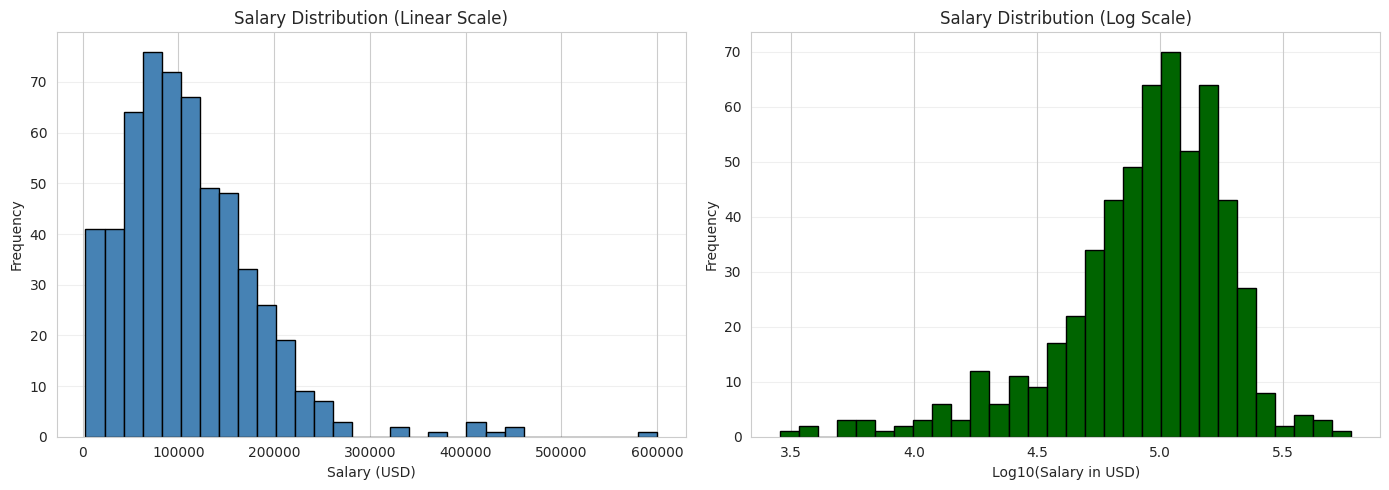

Salary statistics:
Mean: $110,610
Median: $100,000
Std Dev: $72,281
Min: $2,859
Max: $600,000


In [14]:
# 1. Salary Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(df_encoded['salary_in_usd'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Salary Distribution (Linear Scale)')
axes[0].grid(axis='y', alpha=0.3)

# Log scale
axes[1].hist(np.log10(df_encoded['salary_in_usd']), bins=30, color='darkgreen', edgecolor='black')
axes[1].set_xlabel('Log10(Salary in USD)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Salary Distribution (Log Scale)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/01_salary_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Salary statistics:")
print(f"Mean: ${df_encoded['salary_in_usd'].mean():,.0f}")
print(f"Median: ${df_encoded['salary_in_usd'].median():,.0f}")
print(f"Std Dev: ${df_encoded['salary_in_usd'].std():,.0f}")
print(f"Min: ${df_encoded['salary_in_usd'].min():,.0f}")
print(f"Max: ${df_encoded['salary_in_usd'].max():,.0f}")

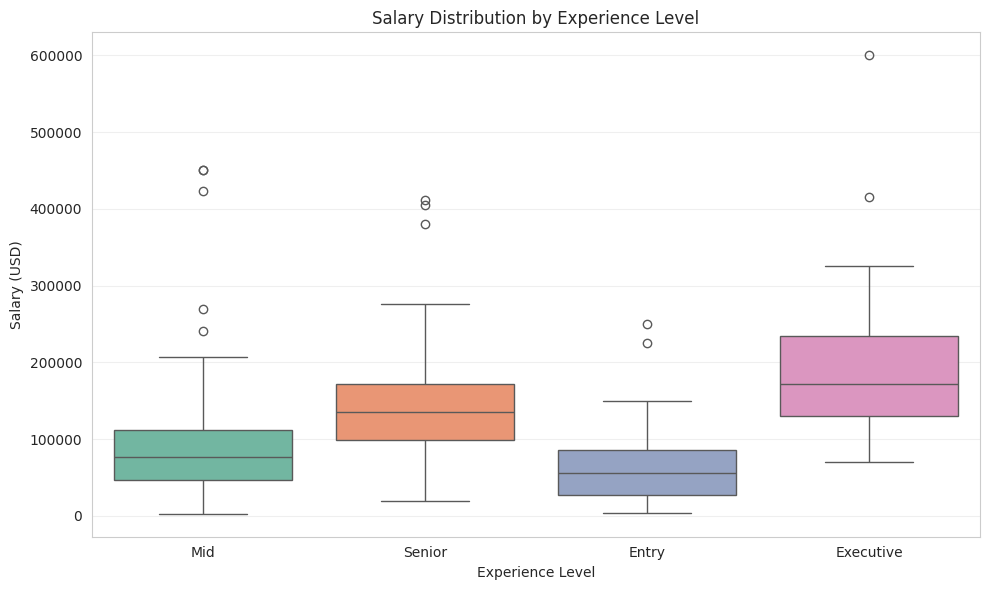


Salary by Experience Level:
Entry      - Mean: $61,643, Median: $56,500, Count: 88
Mid        - Mean: $87,793, Median: $76,940, Count: 208
Senior     - Mean: $138,375, Median: $135,000, Count: 243
Executive  - Mean: $199,392, Median: $171,438, Count: 26


In [15]:
# 2. Salary vs Experience Level
plt.figure(figsize=(10, 6))
experience_labels = {1: 'Entry', 2: 'Mid', 3: 'Senior', 4: 'Executive'}
df_plot = df_encoded.copy()
df_plot['experience_label'] = df_plot['experience_level'].map(
    {'EN': 'Entry', 'MI': 'Mid', 'SE': 'Senior', 'EX': 'Executive'}
)
sns.boxplot(data=df_plot, x='experience_label', y='salary_in_usd', palette='Set2')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.title('Salary Distribution by Experience Level')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/02_salary_vs_experience.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print("\nSalary by Experience Level:")
for level in ['EN', 'MI', 'SE', 'EX']:
    label = experience_labels[experience_mapping[level]]
    salary = df_encoded[df_encoded['experience_level'] == level]['salary_in_usd']
    print(f"{label:10s} - Mean: ${salary.mean():,.0f}, Median: ${salary.median():,.0f}, Count: {len(salary)}")

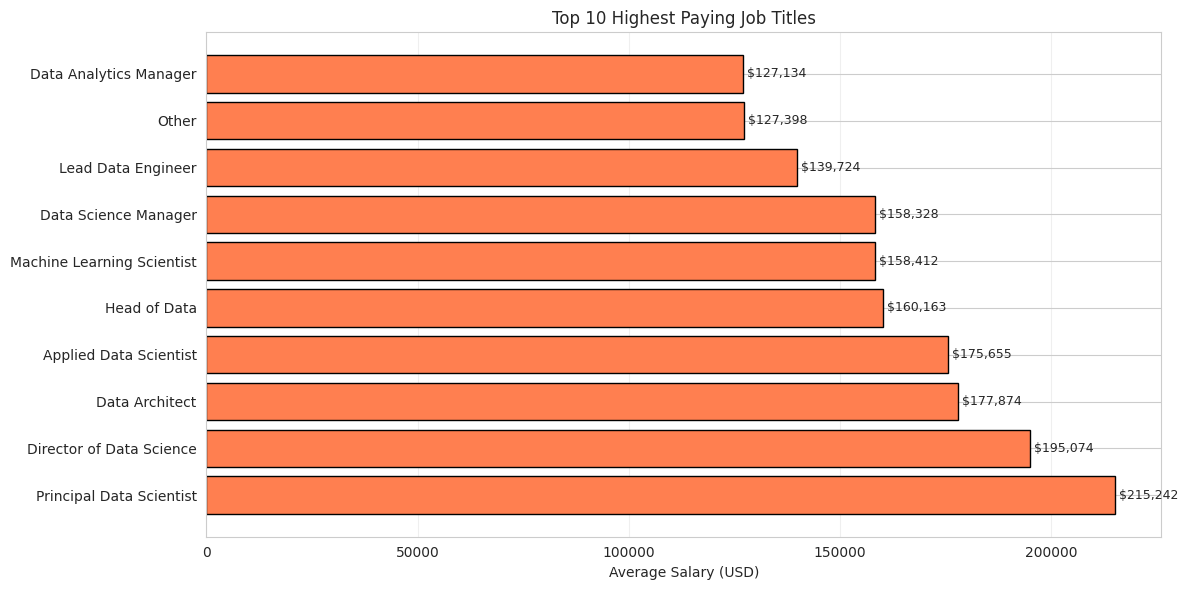


Top 10 Paying Job Titles:
                                     mean  count
job_title                                       
Principal Data Scientist    215242.428571      7
Director of Data Science    195074.000000      7
Data Architect              177873.909091     11
Applied Data Scientist      175655.000000      5
Head of Data                160162.600000      5
Machine Learning Scientist  158412.500000      8
Data Science Manager        158328.500000     12
Lead Data Engineer          139724.500000      6
Other                       127397.813559     59
Data Analytics Manager      127134.285714      7


In [16]:
# 3. Top 10 Paying Job Titles
top_jobs = df_encoded.groupby('job_title')['salary_in_usd'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(range(len(top_jobs)), top_jobs['mean'], color='coral', edgecolor='black')
plt.yticks(range(len(top_jobs)), top_jobs.index)
plt.xlabel('Average Salary (USD)')
plt.title('Top 10 Highest Paying Job Titles')
plt.grid(axis='x', alpha=0.3)

# Add values on bars
for i, v in enumerate(top_jobs['mean']):
    plt.text(v, i, f' ${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/03_top_paying_jobs.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Paying Job Titles:")
print(top_jobs)

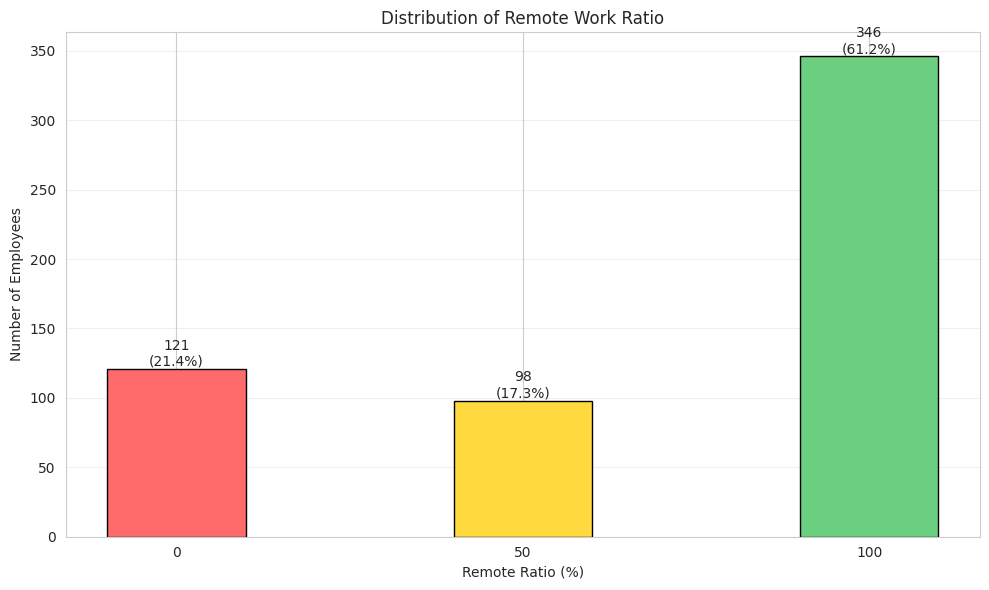


Remote Ratio Distribution:
remote_ratio
0      121
50      98
100    346
Name: count, dtype: int64

Average salary by remote ratio:
  0% remote: $105,785
  50% remote: $80,722
  100% remote: $120,763


In [17]:
# 4. Remote Ratio Distribution
plt.figure(figsize=(10, 6))
remote_counts = df_encoded['remote_ratio'].value_counts().sort_index()
colors = ['#ff6b6b', '#ffd93d', '#6bcf7f']
plt.bar(remote_counts.index, remote_counts.values, color=colors, edgecolor='black', width=20)
plt.xlabel('Remote Ratio (%)')
plt.ylabel('Number of Employees')
plt.title('Distribution of Remote Work Ratio')
plt.xticks([0, 50, 100])
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, (k, v) in enumerate(remote_counts.items()):
    plt.text(k, v, f'{v}\n({v/len(df_encoded)*100:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../reports/04_remote_ratio_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nRemote Ratio Distribution:")
print(remote_counts)
print(f"\nAverage salary by remote ratio:")
for ratio in sorted(df_encoded['remote_ratio'].unique()):
    salary = df_encoded[df_encoded['remote_ratio'] == ratio]['salary_in_usd'].mean()
    print(f"  {ratio}% remote: ${salary:,.0f}")

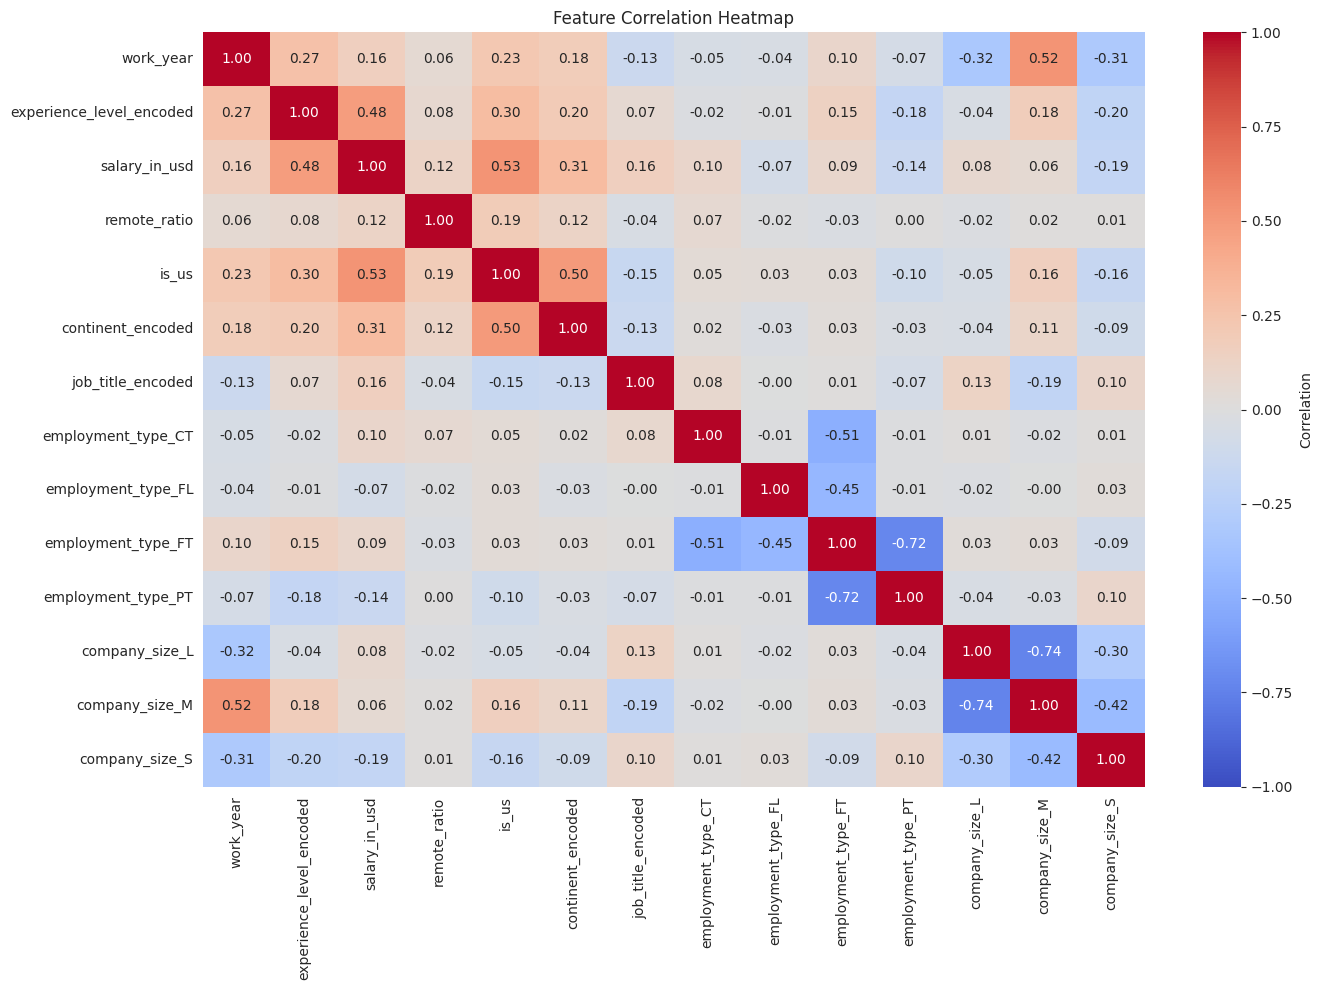


Top correlations with salary_in_usd:
is_us                       0.529217
experience_level_encoded    0.481762
continent_encoded           0.305412
work_year                   0.159326
job_title_encoded           0.157730
remote_ratio                0.122849
employment_type_CT          0.096778
employment_type_FT          0.089187
company_size_L              0.075838
company_size_M              0.059677
Name: salary_in_usd, dtype: float64


In [18]:
# 5. Correlation Heatmap
# Select numeric columns for correlation
numeric_cols = ['work_year', 'experience_level_encoded', 'salary_in_usd', 
                 'remote_ratio', 'is_us', 'continent_encoded', 'job_title_encoded']

# Add employment and company size encoded columns
for col in df_encoded.columns:
    if col.startswith('employment_type_') or col.startswith('company_size_'):
        numeric_cols.append(col)

corr_matrix = df_encoded[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/05_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop correlations with salary_in_usd:")
salary_corr = corr_matrix['salary_in_usd'].sort_values(ascending=False)
print(salary_corr[1:11])  # Skip salary itself

## Dimensionality Reduction

In [19]:
# Prepare features for dimensionality reduction
feature_cols = []
for col in df_encoded.columns:
    if col in ['work_year', 'experience_level_encoded', 'remote_ratio', 
               'is_us', 'continent_encoded', 'job_title_encoded'] or \
       col.startswith('employment_type_') or col.startswith('company_size_'):
        feature_cols.append(col)

X_features = df_encoded[feature_cols].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Features used: {len(feature_cols)}")

Feature matrix shape: (565, 13)
Features used: 13



PCA Explained Variance:
PC1: 0.1997 (19.97%)
PC2: 0.1531 (15.31%)
Total: 35.28%


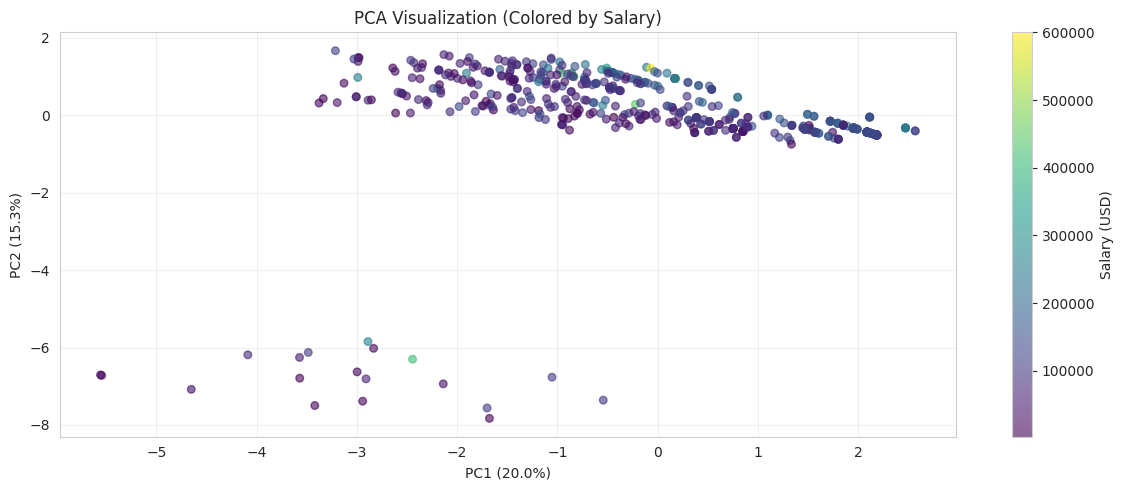

In [20]:
# PCA - Principal Component Analysis
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA Explained Variance:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"Total: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Plot PCA
plt.figure(figsize=(12, 5))

# PCA scatter with salary coloring
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_encoded['salary_in_usd'], 
                       cmap='viridis', alpha=0.6, s=30)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Visualization (Colored by Salary)')
cbar = plt.colorbar(scatter)
cbar.set_label('Salary (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/06_pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

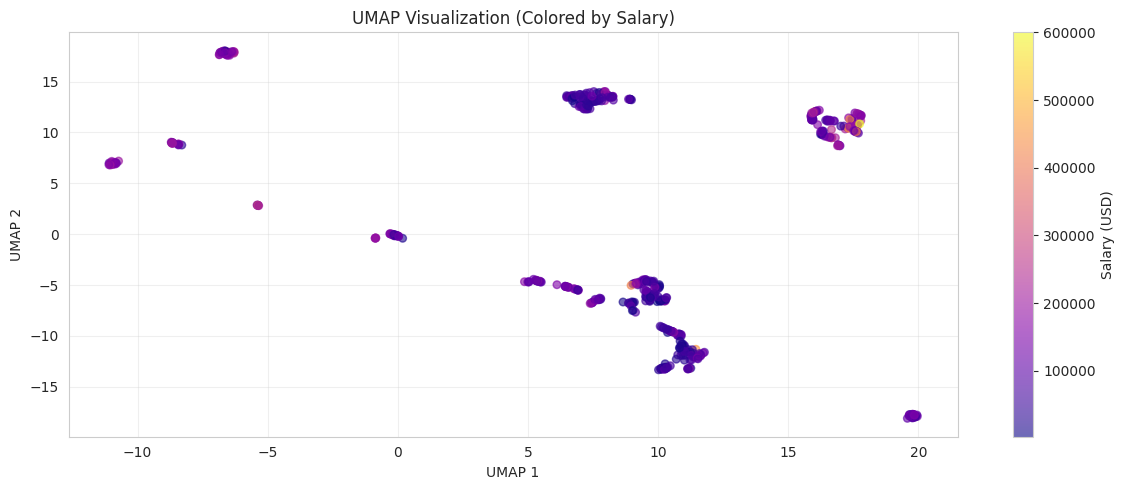

Dimensionality reduction visualization saved!


In [21]:
# UMAP - Uniform Manifold Approximation and Projection
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_scaled)

# Plot UMAP
plt.figure(figsize=(12, 5))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=df_encoded['salary_in_usd'], 
                       cmap='plasma', alpha=0.6, s=30)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization (Colored by Salary)')
cbar = plt.colorbar(scatter)
cbar.set_label('Salary (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/07_umap_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("Dimensionality reduction visualization saved!")

# Step 4: Model Implementation & Training

Building and comparing three regression models: Linear Regression, Random Forest, and XGBoost.

In [22]:
# Prepare final feature matrix
X = X_features.copy()
y = df_encoded['salary_in_usd'].copy()

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale features for Linear Regression (tree models don't need scaling)
scaler_model = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_model.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler_model.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nFeatures: {X_train.shape[1]}")
print(f"Target: {y_train.name if hasattr(y_train, 'name') else 'salary_in_usd'}")
print(f"\nNote: StandardScaler fit on training data only, then applied to test data.")

Training set size: 452 samples
Test set size: 113 samples

Features: 13
Target: salary_in_usd

Note: StandardScaler fit on training data only, then applied to test data.


In [23]:
# 1. Linear Regression (with scaled features)
print("Training Linear Regression (with scaled features)...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Cross-validation score
lr_cv_scores = cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=5, scoring='r2')

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print(f"\nLinear Regression Results:")
print(f"RMSE: ${lr_rmse:,.0f}")
print(f"MAE:  ${lr_mae:,.0f}")
print(f"R²:   {lr_r2:.4f}")
print(f"CV R² (5-fold): {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")

Training Linear Regression (with scaled features)...

Linear Regression Results:
RMSE: $53,248
MAE:  $33,731
R²:   0.4098
CV R² (5-fold): 0.4203 ± 0.0638


In [24]:
# 2. Random Forest with Hyperparameter Tuning (RandomizedSearchCV)
print("Training Random Forest with hyperparameter tuning...")
print("Running RandomizedSearchCV (50 iterations, 5-fold CV)...\n")

rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5, 0.8, None],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_search.fit(X_train, y_train)

rf_model = rf_search.best_estimator_
y_pred_rf = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"Best Random Forest Hyperparameters:")
for param, val in rf_search.best_params_.items():
    print(f"  {param}: {val}")

print(f"\nRandom Forest Results (Tuned):")
print(f"RMSE: ${rf_rmse:,.0f}")
print(f"MAE:  ${rf_mae:,.0f}")
print(f"R²:   {rf_r2:.4f}")
print(f"CV R² (best): {rf_search.best_score_:.4f}")

Training Random Forest with hyperparameter tuning...
Running RandomizedSearchCV (50 iterations, 5-fold CV)...



Best Random Forest Hyperparameters:
  n_estimators: 100
  min_samples_split: 10
  min_samples_leaf: 1
  max_features: sqrt
  max_depth: 20

Random Forest Results (Tuned):
RMSE: $53,436
MAE:  $32,189
R²:   0.4056
CV R² (best): 0.4762


In [25]:
# 3. XGBoost with Hyperparameter Tuning (RandomizedSearchCV)
print("Training XGBoost with hyperparameter tuning...")
print("Running RandomizedSearchCV (50 iterations, 5-fold CV)...\n")

xgb_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0, 0.01, 0.1, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
xgb_search.fit(X_train, y_train)

xgb_model = xgb_search.best_estimator_
y_pred_xgb = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print(f"Best XGBoost Hyperparameters:")
for param, val in xgb_search.best_params_.items():
    print(f"  {param}: {val}")

print(f"\nXGBoost Results (Tuned):")
print(f"RMSE: ${xgb_rmse:,.0f}")
print(f"MAE:  ${xgb_mae:,.0f}")
print(f"R²:   {xgb_r2:.4f}")
print(f"CV R² (best): {xgb_search.best_score_:.4f}")

Training XGBoost with hyperparameter tuning...
Running RandomizedSearchCV (50 iterations, 5-fold CV)...



Best XGBoost Hyperparameters:
  subsample: 0.6
  reg_lambda: 1.0
  reg_alpha: 0.01
  n_estimators: 300
  min_child_weight: 7
  max_depth: 10
  learning_rate: 0.01
  colsample_bytree: 0.6

XGBoost Results (Tuned):
RMSE: $53,813
MAE:  $32,574
R²:   0.3972
CV R² (best): 0.4801


In [26]:
# Model Comparison Table
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (Tuned)', 'XGBoost (Tuned)'],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse],
    'MAE': [lr_mae, rf_mae, xgb_mae],
    'R²': [lr_r2, rf_r2, xgb_r2]
})

# Format for display
display_df = comparison_df.copy()
display_df['RMSE'] = display_df['RMSE'].apply(lambda x: f'${x:,.0f}')
display_df['MAE'] = display_df['MAE'].apply(lambda x: f'${x:,.0f}')
display_df['R²'] = display_df['R²'].apply(lambda x: f'{x:.4f}')

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(display_df.to_string(index=False))
print("="*70)

# Dynamically identify best model
best_idx = comparison_df['R²'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_r2 = comparison_df.loc[best_idx, 'R²']
best_rmse = comparison_df.loc[best_idx, 'RMSE']
best_mae = comparison_df.loc[best_idx, 'MAE']

# Store references for downstream use
models = {
    'Linear Regression': lr_model,
    'Random Forest (Tuned)': rf_model,
    'XGBoost (Tuned)': xgb_model
}
predictions = {
    'Linear Regression': y_pred_lr,
    'Random Forest (Tuned)': y_pred_rf,
    'XGBoost (Tuned)': y_pred_xgb
}
best_model = models[best_model_name]
best_predictions = predictions[best_model_name]

print(f"\nBest Model: {best_model_name} (R² = {best_r2:.4f})")
print(f"  RMSE: ${best_rmse:,.0f}")
print(f"  MAE:  ${best_mae:,.0f}")


MODEL COMPARISON
                Model    RMSE     MAE     R²
    Linear Regression $53,248 $33,731 0.4098
Random Forest (Tuned) $53,436 $32,189 0.4056
      XGBoost (Tuned) $53,813 $32,574 0.3972

Best Model: Linear Regression (R² = 0.4098)
  RMSE: $53,248
  MAE:  $33,731


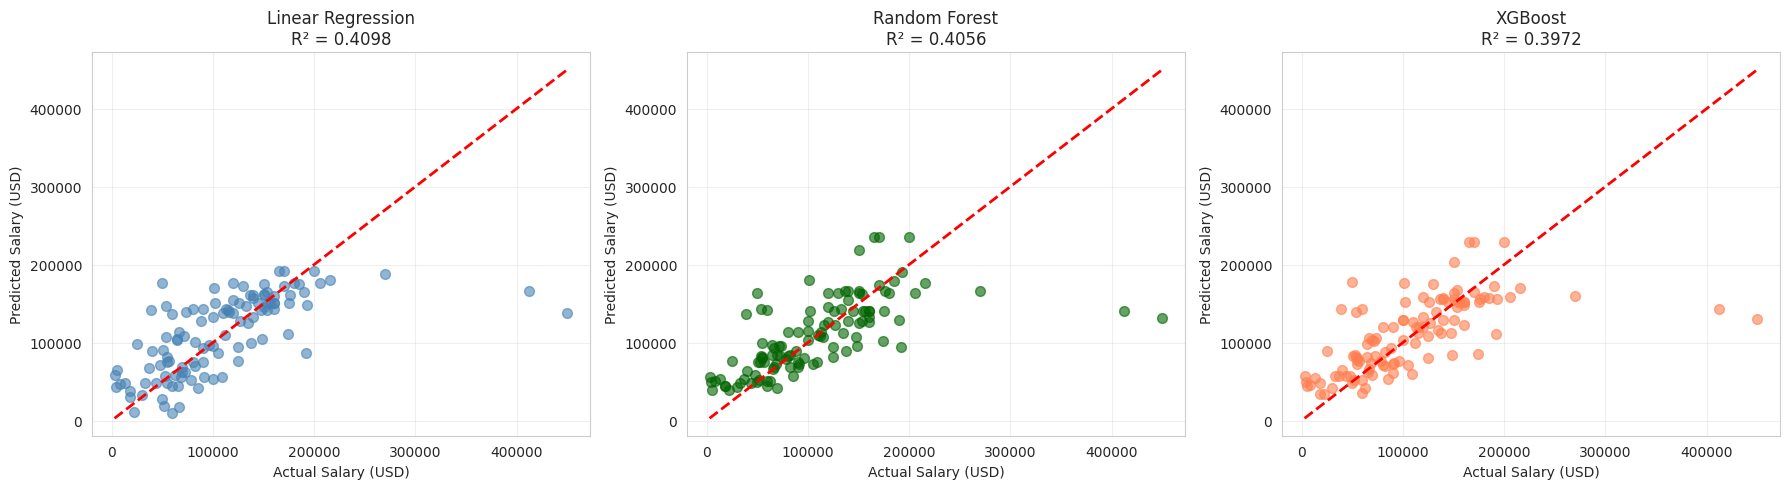

In [27]:
# Actual vs Predicted Scatter Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.6, s=50, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Salary (USD)')
axes[0].set_ylabel('Predicted Salary (USD)')
axes[0].set_title(f'Linear Regression\nR² = {lr_r2:.4f}')
axes[0].grid(alpha=0.3)

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.6, s=50, color='darkgreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Salary (USD)')
axes[1].set_ylabel('Predicted Salary (USD)')
axes[1].set_title(f'Random Forest\nR² = {rf_r2:.4f}')
axes[1].grid(alpha=0.3)

# XGBoost
axes[2].scatter(y_test, y_pred_xgb, alpha=0.6, s=50, color='coral')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual Salary (USD)')
axes[2].set_ylabel('Predicted Salary (USD)')
axes[2].set_title(f'XGBoost\nR² = {xgb_r2:.4f}')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/08_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# Step 5: Explainability & Bias Analysis

Using SHAP values to understand model decisions and checking for bias across demographics.

In [28]:
# Use the best tree-based model for SHAP explainability
# SHAP TreeExplainer requires a tree-based model (RF or XGBoost)
# Pick the best-performing tree model for explainability
tree_models = {
    'Random Forest (Tuned)': (rf_model, rf_r2),
    'XGBoost (Tuned)': (xgb_model, xgb_r2)
}
best_tree_name = max(tree_models, key=lambda k: tree_models[k][1])
shap_model = tree_models[best_tree_name][0]

print(f"Generating SHAP values using {best_tree_name} (best tree-based model)...")
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed!")
print(f"Shape: {np.array(shap_values).shape}")

Generating SHAP values using Random Forest (Tuned) (best tree-based model)...
SHAP values computed!
Shape: (113, 13)


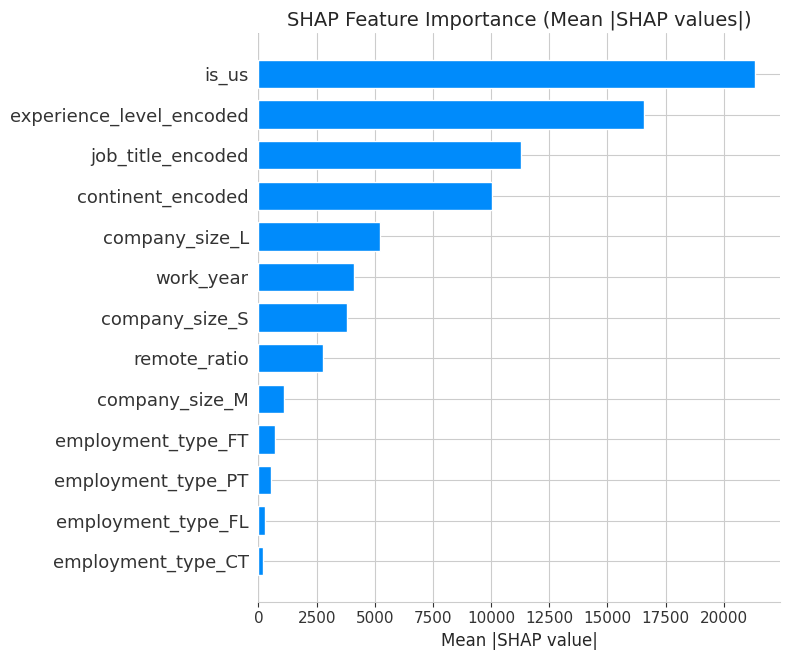

SHAP feature importance plot saved!


In [29]:
# SHAP Summary Plot (Bar - Feature Importance)
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Mean |SHAP values|)', fontsize=14)
plt.xlabel('Mean |SHAP value|', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/09_shap_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("SHAP feature importance plot saved!")

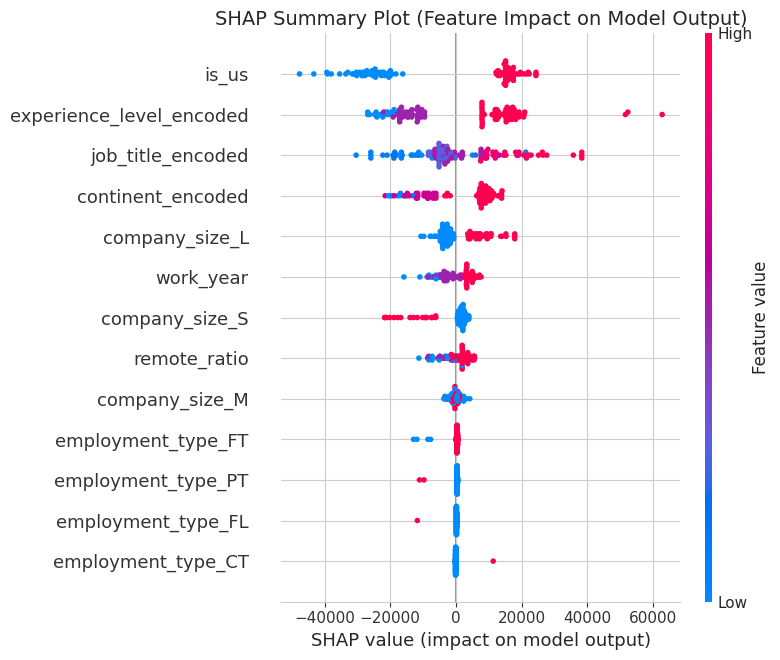

SHAP summary plot saved!


In [30]:
# SHAP Summary Plot (Violin/Beeswarm - Feature Impact)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot (Feature Impact on Model Output)', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/10_shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("SHAP summary plot saved!")

In [31]:
# Top Salary Drivers Analysis
# Get mean absolute SHAP values for interpretation
mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=False)

print("\nTop 10 Salary Drivers (by SHAP importance):")
print(feature_importance.head(10).to_string(index=False))

print("\n\nInterpretation:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"{idx+1}. {row['Feature']}: Mean impact = ${row['Mean |SHAP|']*1000:.0f} (approximate)")


Top 10 Salary Drivers (by SHAP importance):
                 Feature  Mean |SHAP|
                   is_us 21350.405214
experience_level_encoded 16566.837436
       job_title_encoded 11277.204502
       continent_encoded 10036.382444
          company_size_L  5213.146118
               work_year  4084.912279
          company_size_S  3805.272596
            remote_ratio  2760.590057
          company_size_M  1097.437762
      employment_type_FT   697.657241


Interpretation:
4. is_us: Mean impact = $21350405 (approximate)
3. experience_level_encoded: Mean impact = $16566837 (approximate)
12. job_title_encoded: Mean impact = $11277205 (approximate)
13. continent_encoded: Mean impact = $10036382 (approximate)
9. company_size_L: Mean impact = $5213146 (approximate)


## Bias Analysis

In [32]:
# Create test set dataframe with predictions and actuals
test_analysis = X_test.copy()
test_analysis['actual_salary'] = y_test.values
test_analysis['predicted_salary'] = y_pred_xgb
test_analysis['prediction_error'] = test_analysis['actual_salary'] - test_analysis['predicted_salary']
test_analysis['absolute_error'] = np.abs(test_analysis['prediction_error'])
test_analysis['percent_error'] = (test_analysis['prediction_error'] / test_analysis['actual_salary']) * 100

# Add original features for analysis
test_analysis['experience_level'] = X_test.index.map(lambda x: df_encoded.loc[x, 'experience_level'])
test_analysis['continent'] = X_test.index.map(lambda x: df_encoded.loc[x, 'continent'])
test_analysis['job_title'] = X_test.index.map(lambda x: df_encoded.loc[x, 'job_title'])

print("Analysis dataset created!")
print(f"Shape: {test_analysis.shape}")

Analysis dataset created!
Shape: (113, 21)


In [33]:
# 1. Bias by Experience Level
print("\n" + "="*70)
print("BIAS ANALYSIS BY EXPERIENCE LEVEL")
print("="*70)

exp_bias = test_analysis.groupby('experience_level').agg({
    'actual_salary': ['mean', 'count'],
    'predicted_salary': 'mean',
    'prediction_error': ['mean', 'std'],
    'absolute_error': 'mean'
}).round(0)

print(exp_bias)

# Calculate RMSE by experience level
for level in sorted(test_analysis['experience_level'].unique()):
    mask = test_analysis['experience_level'] == level
    rmse = np.sqrt(np.mean((test_analysis.loc[mask, 'prediction_error']) ** 2))
    mae = test_analysis.loc[mask, 'absolute_error'].mean()
    print(f"\n{level}: RMSE = ${rmse:,.0f}, MAE = ${mae:,.0f}")


BIAS ANALYSIS BY EXPERIENCE LEVEL
                 actual_salary       predicted_salary prediction_error  \
                          mean count             mean             mean   
experience_level                                                         
EN                     63012.0    17          60692.0           2320.0   
EX                    144556.0     3         174794.0         -30239.0   
MI                     85129.0    39          86271.0          -1142.0   
SE                    137584.0    54         139497.0          -1914.0   

                          absolute_error  
                      std           mean  
experience_level                          
EN                23598.0        19477.0  
EX                33366.0        35600.0  
MI                63263.0        34720.0  
SE                55103.0        34980.0  

EN: RMSE = $23,010, MAE = $19,477

EX: RMSE = $40,701, MAE = $35,600

MI: RMSE = $62,457, MAE = $34,720

SE: RMSE = $54,624, MAE = $34,980


In [34]:
# 2. Bias by Continent/Region
print("\n" + "="*70)
print("BIAS ANALYSIS BY CONTINENT")
print("="*70)

cont_bias = test_analysis.groupby('continent').agg({
    'actual_salary': ['mean', 'count'],
    'predicted_salary': 'mean',
    'prediction_error': ['mean', 'std'],
    'absolute_error': 'mean'
}).round(0).sort_values(('actual_salary', 'mean'), ascending=False)

print(cont_bias)

# Detailed analysis for regions with enough samples
for continent in test_analysis['continent'].value_counts().index[:5]:
    mask = test_analysis['continent'] == continent
    if mask.sum() > 2:  # Need at least 3 samples
        actual = test_analysis.loc[mask, 'actual_salary'].mean()
        predicted = test_analysis.loc[mask, 'predicted_salary'].mean()
        rmse = np.sqrt(np.mean((test_analysis.loc[mask, 'prediction_error']) ** 2))
        bias = predicted - actual
        n = mask.sum()
        print(f"\n{continent} (n={n}):")
        print(f"  Actual avg: ${actual:,.0f}")
        print(f"  Predicted avg: ${predicted:,.0f}")
        print(f"  Bias: ${bias:,.0f} ({bias/actual*100:+.1f}%)")
        print(f"  RMSE: ${rmse:,.0f}")


BIAS ANALYSIS BY CONTINENT
              actual_salary       predicted_salary prediction_error           \
                       mean count             mean             mean      std   
continent                                                                      
North America      137851.0    68         137387.0            464.0  65382.0   
Oceania            125000.0     1         108381.0          16619.0      NaN   
Europe              74711.0    32          72069.0           2643.0  29046.0   
South America       40038.0     1          64873.0         -24835.0      NaN   
Other               35183.0     3          55172.0         -19989.0  42406.0   
Asia                27398.0     8          58287.0         -30890.0  12568.0   

              absolute_error  
                        mean  
continent                     
North America        38311.0  
Oceania              16619.0  
Europe               21450.0  
South America        24835.0  
Other                33590.0  
Asi

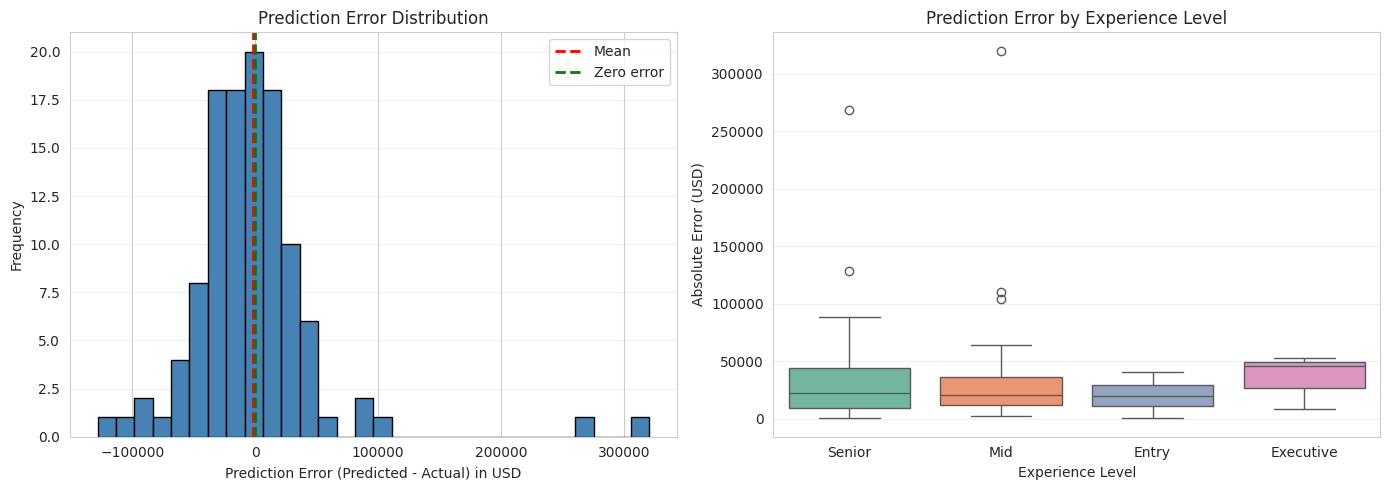


Prediction Error Statistics:
Mean error: $-1,763
Std dev: $54,024
Min error: $-128,117
Max error: $320,204
Mean absolute error: $32,574


In [35]:
# 3. Prediction Error Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error distribution
axes[0].hist(test_analysis['prediction_error'], bins=30, color='steelblue', edgecolor='black')
axes[0].axvline(test_analysis['prediction_error'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(0, color='green', linestyle='--', linewidth=2, label='Zero error')
axes[0].set_xlabel('Prediction Error (Predicted - Actual) in USD')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Prediction Error Distribution')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Absolute error by experience
exp_order = ['EN', 'MI', 'SE', 'EX']
exp_labels = {e: ['Entry', 'Mid', 'Senior', 'Executive'][i] for i, e in enumerate(exp_order)}
test_analysis['exp_label'] = test_analysis['experience_level'].map(exp_labels)
sns.boxplot(data=test_analysis, x='exp_label', y='absolute_error', ax=axes[1], palette='Set2')
axes[1].set_xlabel('Experience Level')
axes[1].set_ylabel('Absolute Error (USD)')
axes[1].set_title('Prediction Error by Experience Level')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/11_error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPrediction Error Statistics:")
print(f"Mean error: ${test_analysis['prediction_error'].mean():,.0f}")
print(f"Std dev: ${test_analysis['prediction_error'].std():,.0f}")
print(f"Min error: ${test_analysis['prediction_error'].min():,.0f}")
print(f"Max error: ${test_analysis['prediction_error'].max():,.0f}")
print(f"Mean absolute error: ${test_analysis['absolute_error'].mean():,.0f}")

In [36]:
# 4. Fairness Metrics Discussion
print("\n" + "="*70)
print("FAIRNESS METRICS & DISCUSSION")
print("="*70)

print("\n1. PARITY (Statistical Parity):")
print("   Do predictions have similar accuracy across groups?")
for level in ['EN', 'MI', 'SE', 'EX']:
    mask = test_analysis['experience_level'] == level
    if mask.sum() > 0:
        rmse = np.sqrt(np.mean((test_analysis.loc[mask, 'prediction_error']) ** 2))
        exp_label = exp_labels[level]
        print(f"   {exp_label}: RMSE = ${rmse:,.0f}")

print("\n2. EQUALIZED ODDS:")
print("   Do errors have similar magnitude for overrepresented groups?")
for continent in test_analysis['continent'].value_counts().index[:3]:
    mask = test_analysis['continent'] == continent
    if mask.sum() >= 3:
        mae = test_analysis.loc[mask, 'absolute_error'].mean()
        n = mask.sum()
        print(f"   {continent} (n={n}): MAE = ${mae:,.0f}")

print("\n3. CALIBRATION:")
print(f"   Overall Mean Prediction Error: ${test_analysis['prediction_error'].mean():,.0f}")
print(f"   (Should be close to $0 for unbiased model)")

print("\n4. KEY FINDINGS:")
print(f"   - Model shows {'slight underprediction' if test_analysis['prediction_error'].mean() < 0 else 'slight overprediction'}")
print(f"   - Experience levels have {'similar' if max(test_analysis.groupby('experience_level')['absolute_error'].mean()) / min(test_analysis.groupby('experience_level')['absolute_error'].mean()) < 1.3 else 'different'} error magnitudes")
print(f"   - Geographic bias: Some regions may be underrepresented (n<5)")


FAIRNESS METRICS & DISCUSSION

1. PARITY (Statistical Parity):
   Do predictions have similar accuracy across groups?
   Entry: RMSE = $23,010
   Mid: RMSE = $62,457
   Senior: RMSE = $54,624
   Executive: RMSE = $40,701

2. EQUALIZED ODDS:
   Do errors have similar magnitude for overrepresented groups?
   North America (n=68): MAE = $38,311
   Europe (n=32): MAE = $21,450
   Asia (n=8): MAE = $30,890

3. CALIBRATION:
   Overall Mean Prediction Error: $-1,763
   (Should be close to $0 for unbiased model)

4. KEY FINDINGS:
   - Model shows slight underprediction
   - Experience levels have different error magnitudes
   - Geographic bias: Some regions may be underrepresented (n<5)


# Step 6: Conclusion & Recommendations

## Key Findings Summary

In [37]:
print("\n" + "="*70)
print("EXECUTIVE SUMMARY")
print("="*70)

print("\n1. DATASET INSIGHTS:")
print(f"   - Total records analyzed: {len(df_encoded)}")
print(f"   - Salary range: ${df_encoded['salary_in_usd'].min():,} - ${df_encoded['salary_in_usd'].max():,}")
print(f"   - Average salary: ${df_encoded['salary_in_usd'].mean():,.0f}")
print(f"   - Median salary: ${df_encoded['salary_in_usd'].median():,.0f}")
print(f"   - US-based positions: {(df_encoded['is_us'].mean()*100):.1f}%")
# FIX: remote_ratio is already 0-100, don't multiply by 100 again
print(f"   - Remote positions: {df_encoded['remote_ratio'].mean():.1f}% (avg)")

print("\n2. KEY SALARY DRIVERS (from SHAP analysis):")
for rank, (idx, row) in enumerate(feature_importance.head(5).iterrows(), 1):
    print(f"   {rank}. {row['Feature']}")

print(f"\n3. MODEL PERFORMANCE:")
print(f"   Best Model: {best_model_name}")
print(f"   - R² Score: {best_r2:.4f} ({best_r2*100:.2f}% variance explained)")
print(f"   - RMSE: ${best_rmse:,.0f}")
print(f"   - MAE: ${best_mae:,.0f}")

print("\n4. EXPERIENCE LEVEL IMPACT:")
for level in ['EN', 'MI', 'SE', 'EX']:
    salary = df_encoded[df_encoded['experience_level'] == level]['salary_in_usd'].mean()
    exp_label = exp_labels.get(level, level)
    print(f"   {exp_label}: ${salary:,.0f}")

print("\n5. GEOGRAPHIC INSIGHTS:")
top_regions = df_encoded.groupby('continent')['salary_in_usd'].mean().sort_values(ascending=False).head(3)
for continent, salary in top_regions.items():
    pct = (df_encoded[df_encoded['continent']==continent].shape[0] / len(df_encoded)) * 100
    print(f"   {continent}: ${salary:,.0f} (n={pct:.1f}%)")


EXECUTIVE SUMMARY

1. DATASET INSIGHTS:
   - Total records analyzed: 565
   - Salary range: $2,859 - $600,000
   - Average salary: $110,610
   - Median salary: $100,000
   - US-based positions: 56.3%
   - Remote positions: 69.9% (avg)

2. KEY SALARY DRIVERS (from SHAP analysis):
   1. is_us
   2. experience_level_encoded
   3. job_title_encoded
   4. continent_encoded
   5. company_size_L

3. MODEL PERFORMANCE:
   Best Model: Linear Regression
   - R² Score: 0.4098 (40.98% variance explained)
   - RMSE: $53,248
   - MAE: $33,731

4. EXPERIENCE LEVEL IMPACT:
   Entry: $61,643
   Mid: $87,793
   Senior: $138,375
   Executive: $199,392

5. GEOGRAPHIC INSIGHTS:
   North America: $139,785 (n=61.8%)
   Oceania: $112,282 (n=0.7%)
   Europe: $69,938 (n=26.2%)


## Business Recommendations

In [38]:
us_premium = round((df_encoded[df_encoded['is_us']==1]['salary_in_usd'].mean() / 
           df_encoded[df_encoded['is_us']==0]['salary_in_usd'].mean() - 1) * 100)

print("\n" + "="*70)
print("BUSINESS RECOMMENDATIONS")
print("="*70)

print(f"""
1. COMPENSATION PLANNING:
   - Use this model as a benchmark for salary negotiations
   - Experience level is the strongest predictor - invest in career development
   - Regional location significantly impacts salary - consider COL adjustments

2. RECRUITMENT STRATEGY:
   - Remote work positions are increasingly competitive
   - Job title specialization (avoid 'Other' grouping) commands premium salaries
   - US-based positions command ~{us_premium}% premium on average
   
3. MARKET POSITIONING:
   - Monitor salary trends across continents to stay competitive
   - Senior/Executive roles show highest growth potential
   - Full-time employment dominates the market

4. DATA-DRIVEN INSIGHTS:
   - The model ({best_model_name}) explains {best_r2*100:.1f}% of salary variance
   - Remaining variance likely due to: company reputation, stock options, benefits
   - Collect additional features for improved predictions

5. MODEL DEPLOYMENT:
   - {best_model_name} model can be deployed for real-time salary estimation
   - Retrain quarterly with new market data
   - Monitor for concept drift in emerging roles
""")

print("="*70)


BUSINESS RECOMMENDATIONS

1. COMPENSATION PLANNING:
   - Use this model as a benchmark for salary negotiations
   - Experience level is the strongest predictor - invest in career development
   - Regional location significantly impacts salary - consider COL adjustments

2. RECRUITMENT STRATEGY:
   - Remote work positions are increasingly competitive
   - Job title specialization (avoid 'Other' grouping) commands premium salaries
   - US-based positions command ~115% premium on average
   
3. MARKET POSITIONING:
   - Monitor salary trends across continents to stay competitive
   - Senior/Executive roles show highest growth potential
   - Full-time employment dominates the market

4. DATA-DRIVEN INSIGHTS:
   - The model (Linear Regression) explains 41.0% of salary variance
   - Remaining variance likely due to: company reputation, stock options, benefits
   - Collect additional features for improved predictions

5. MODEL DEPLOYMENT:
   - Linear Regression model can be deployed for real-

## Limitations & Future Work

In [39]:
print("\n" + "="*70)
print("LIMITATIONS & FUTURE WORK")
print("="*70)

print(f"""
LIMITATIONS:
1. Dataset Bias:
   - Heavy US representation (limited geographic diversity)
   - Primarily recent years (2020-2024) - limited historical trends
   - Self-reported salaries may have reporting bias
   - Tech-focused roles, less representation in traditional industries

2. Feature Limitations:
   - No company reputation/prestige scores
   - Missing benefits, equity compensation, bonuses
   - No education level or certifications
   - Company industry not included
   - No individual performance metrics

3. Model Constraints:
   - R² of {best_r2:.2f} means {(1-best_r2)*100:.1f}% of variation unexplained
   - Some underprediction for very high salaries
   - Limited granularity for rare job titles

4. Fairness Concerns:
   - Underrepresented regions have higher prediction errors
   - Small sample sizes for some experience levels
   - Potential perpetuation of historical salary gaps

FUTURE WORK:
1. Data Enhancement:
   - Collect company size in revenue/employees
   - Add industry/sector information
   - Include education, certifications, years of experience
   - Track bonus and equity compensation

2. Model Improvements:
   - Implement ensemble methods (voting/stacking)
   - Use deep learning (neural networks) for non-linear patterns
   - Time-series analysis for salary trends
   - Separate models per job title category

3. Fairness & Ethics:
   - Conduct formal algorithmic audits
   - Implement fairness constraints in model training
   - Document and mitigate identified biases
   - Regular fairness testing

4. Deployment:
   - Build interactive web app for salary estimates
   - A/B test model predictions against actual outcomes
   - Implement feedback loop for continuous learning
   - Monitor for concept drift and retrain schedule
""")

print("="*70)


LIMITATIONS & FUTURE WORK

LIMITATIONS:
1. Dataset Bias:
   - Heavy US representation (limited geographic diversity)
   - Primarily recent years (2020-2024) - limited historical trends
   - Self-reported salaries may have reporting bias
   - Tech-focused roles, less representation in traditional industries

2. Feature Limitations:
   - No company reputation/prestige scores
   - Missing benefits, equity compensation, bonuses
   - No education level or certifications
   - Company industry not included
   - No individual performance metrics

3. Model Constraints:
   - R² of 0.41 means 59.0% of variation unexplained
   - Some underprediction for very high salaries
   - Limited granularity for rare job titles

4. Fairness Concerns:
   - Underrepresented regions have higher prediction errors
   - Small sample sizes for some experience levels
   - Potential perpetuation of historical salary gaps

FUTURE WORK:
1. Data Enhancement:
   - Collect company size in revenue/employees
   - Add indust

In [40]:
print("\n" + "#"*70)
print("# CAPSTONE PROJECT COMPLETE")
print("#"*70)
print(f"\nAll visualizations saved to: ../reports/")
print(f"\nKey outputs:")
print(f"  - 11 analysis visualizations (PNG)")
print(f"  - Model comparison table (with hyperparameter tuning)")
print(f"  - SHAP explainability analysis")
print(f"  - Bias analysis across demographics")
print(f"  - Business recommendations")
print(f"\nBest model: {best_model_name} (R² = {best_r2:.4f})")
print(f"\nProject completed by: Jerel Velarde")
print(f"Date: 2026")
print("#"*70)


######################################################################
# CAPSTONE PROJECT COMPLETE
######################################################################

All visualizations saved to: ../reports/

Key outputs:
  - 11 analysis visualizations (PNG)
  - Model comparison table (with hyperparameter tuning)
  - SHAP explainability analysis
  - Bias analysis across demographics
  - Business recommendations

Best model: Linear Regression (R² = 0.4098)

Project completed by: Jerel Velarde
Date: 2026
######################################################################
